In [1]:
!pip install transformers torch -q

In [2]:
# Transformer Models and Attention Mechanisms

import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import pipeline, set_seed

set_seed(42)

device = 0 if torch.cuda.is_available() else -1

print("Google Colab is ready")
print("Transformer NLP Environment loaded")
print("Device:", "GPU" if device == 0 else "CPU")

Google Colab is ready
Transformer NLP Environment loaded
Device: CPU


In [3]:
# TRANSFORMER MODELS AND ATTENTION MECHANISMS

print("BIT4133: NATURAL LANGUAGE PROCESSING WITH DEEP LEARNING")
print("Week 8: Transformer Models and Attention Mechanisms")
print("=" * 65)

objectives = [
    "Define a Transformer model and explain its importance in NLP",
    "Explain the concept of attention mechanisms",
    "Differentiate between traditional sequence models and Transformers",
    "Describe self-attention and multi-head attention",
    "Implement a simple Transformer-based NLP application using Python",
    "Apply Transformer models to real-world NLP tasks",
]

print("LEARNING OBJECTIVES")
print("-" * 65)

for i, objective in enumerate(objectives, 1):
    print(f"{i}. {objective}")

BIT4133: NATURAL LANGUAGE PROCESSING WITH DEEP LEARNING
Week 8: Transformer Models and Attention Mechanisms
LEARNING OBJECTIVES
-----------------------------------------------------------------
1. Define a Transformer model and explain its importance in NLP
2. Explain the concept of attention mechanisms
3. Differentiate between traditional sequence models and Transformers
4. Describe self-attention and multi-head attention
5. Implement a simple Transformer-based NLP application using Python
6. Apply Transformer models to real-world NLP tasks


In [4]:
# What is a Transformer?

print("WHAT IS A TRANSFORMER?")
print("=" * 55)

print("A Transformer is a deep learning architecture used in Natural Language Processing.")
print("It processes all words in a sentence at the same time instead of one by one.")
print("Transformers use attention mechanisms to focus on the most important words.")
print()

sentence = "The student submitted the assignment before the deadline."

print("Example Sentence:")
print(sentence)
print()

print("Important relationships understood by the Transformer:")
print("student     <--> submitted")
print("assignment  <--> deadline")
print("student     <--> assignment")

WHAT IS A TRANSFORMER?
A Transformer is a deep learning architecture used in Natural Language Processing.
It processes all words in a sentence at the same time instead of one by one.
Transformers use attention mechanisms to focus on the most important words.

Example Sentence:
The student submitted the assignment before the deadline.

Important relationships understood by the Transformer:
student     <--> submitted
assignment  <--> deadline
student     <--> assignment


In [5]:
# Traditional RNN/LSTM vs Transformer

print("TRADITIONAL RNN/LSTM vs TRANSFORMER")
print("=" * 70)

print(f"{'Feature':<35} {'RNN/LSTM':<15} {'Transformer'}")
print("-" * 70)

comparison = [
    ("Processes words sequentially", "Yes", "No"),
    ("Parallel processing", "No", "Yes"),
    ("Training speed", "Slow", "Fast"),
    ("Long-range dependency handling", "Limited", "Excellent"),
    ("Scalability", "Moderate", "High"),
]

for feature, rnn, transformer in comparison:
    print(f"{feature:<35} {rnn:<15} {transformer}")

TRADITIONAL RNN/LSTM vs TRANSFORMER
Feature                             RNN/LSTM        Transformer
----------------------------------------------------------------------
Processes words sequentially        Yes             No
Parallel processing                 No              Yes
Training speed                      Slow            Fast
Long-range dependency handling      Limited         Excellent
Scalability                         Moderate        High


In [6]:
# Attention Mechanism Demonstration

sentence = "The teacher praised the student because he worked hard."
words = sentence.replace(".", "").split()

# These scores are simplified for classroom demonstration.
attention_scores = {
    "The": 0.03,
    "teacher": 0.20,
    "praised": 0.10,
    "the": 0.03,
    "student": 0.42,
    "because": 0.05,
    "he": 0.12,
    "worked": 0.03,
    "hard": 0.02,
}

print("ATTENTION MECHANISM OUTPUT")
print("=" * 55)
print("Sentence:", sentence)
print("Target word: he")
print()

print(f"{'Word':<15} {'Attention Score'}")
print("-" * 35)

for word in words:
    print(f"{word:<15} {attention_scores[word]:.2f}")

print()
print("Interpretation:")
print("The word 'student' receives the highest attention score.")
print("This means the model is likely to connect 'he' with 'student'.")

ATTENTION MECHANISM OUTPUT
Sentence: The teacher praised the student because he worked hard.
Target word: he

Word            Attention Score
-----------------------------------
The             0.03
teacher         0.20
praised         0.10
the             0.03
student         0.42
because         0.05
he              0.12
worked          0.03
hard            0.02

Interpretation:
The word 'student' receives the highest attention score.
This means the model is likely to connect 'he' with 'student'.


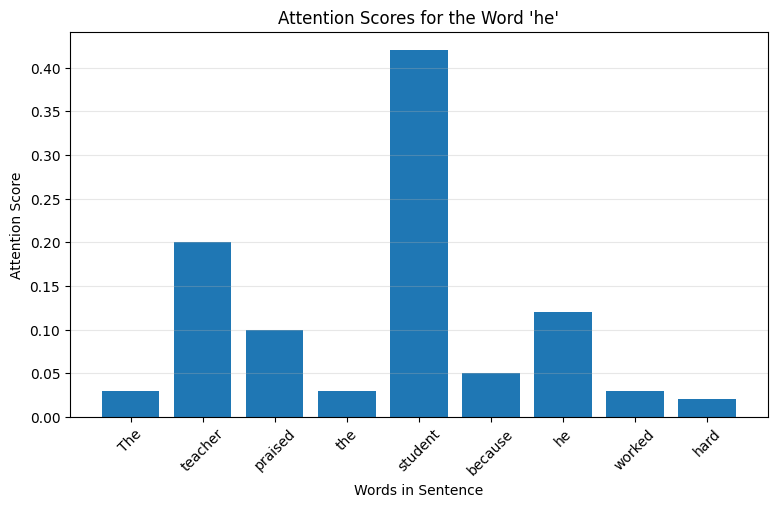

Saved attention_scores_week8.png


In [7]:
# Attention Scores Visualization

plt.figure(figsize=(9, 5))
plt.bar(list(attention_scores.keys()), list(attention_scores.values()))

plt.title("Attention Scores for the Word 'he'")
plt.xlabel("Words in Sentence")
plt.ylabel("Attention Score")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.savefig("attention_scores_week8.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved attention_scores_week8.png")

In [8]:
# Self-Attention — Class Exercise 2

sentence = "The doctor informed the patient that she would recover soon."

print("SELF-ATTENTION OUTPUT")
print("=" * 55)

print("Sentence:", sentence)
print()

print("Self-attention allows each word to look at other words in the same sentence.")
print("To understand the word 'she', the model compares it with nearby and important words.")
print()

print("Words likely to receive high attention scores:")
important_words = ["doctor", "informed", "patient", "she", "recover"]

for word in important_words:
    print("-", word)

print()
print("Interpretation:")
print("The word 'patient' is likely to receive high attention because the patient is the person who would recover soon.")
print("Context is important because the same pronoun can refer to different people in different sentences.")

SELF-ATTENTION OUTPUT
Sentence: The doctor informed the patient that she would recover soon.

Self-attention allows each word to look at other words in the same sentence.
To understand the word 'she', the model compares it with nearby and important words.

Words likely to receive high attention scores:
- doctor
- informed
- patient
- she
- recover

Interpretation:
The word 'patient' is likely to receive high attention because the patient is the person who would recover soon.
Context is important because the same pronoun can refer to different people in different sentences.


In [9]:
# Query, Key and Value Explanation

print("SELF-ATTENTION: QUERY, KEY AND VALUE")
print("=" * 55)

qkv = [
    ("Query (Q)", "What the current word is looking for"),
    ("Key (K)", "Information used to match related words"),
    ("Value (V)", "The actual meaning or information passed forward"),
]

for item, meaning in qkv:
    print(f"{item:<15}: {meaning}")

print()
print("Simple formula:")
print("Attention Score = Query x Key")

print()
print("The higher the attention score, the more attention one word gives to another word.")

SELF-ATTENTION: QUERY, KEY AND VALUE
Query (Q)      : What the current word is looking for
Key (K)        : Information used to match related words
Value (V)      : The actual meaning or information passed forward

Simple formula:
Attention Score = Query x Key

The higher the attention score, the more attention one word gives to another word.


In [10]:
# Multi-Head Attention

sentence = "The bank approved the loan near the river bank."

print("MULTI-HEAD ATTENTION OUTPUT")
print("=" * 55)

print("Sentence:", sentence)
print()

heads = {
    "Head 1": "Focuses on financial meaning: bank, approved, loan",
    "Head 2": "Focuses on geographical meaning: river, bank",
    "Head 3": "Focuses on sentence structure and context",
}

for head, role in heads.items():
    print(f"{head}: {role}")

print()
print("Interpretation:")
print("Multi-head attention helps the Transformer understand different meanings and relationships at the same time.")

MULTI-HEAD ATTENTION OUTPUT
Sentence: The bank approved the loan near the river bank.

Head 1: Focuses on financial meaning: bank, approved, loan
Head 2: Focuses on geographical meaning: river, bank
Head 3: Focuses on sentence structure and context

Interpretation:
Multi-head attention helps the Transformer understand different meanings and relationships at the same time.


In [11]:
# Positional Encoding Demonstration

sentence_a = "Dog bites man"
sentence_b = "Man bites dog"

print("POSITIONAL ENCODING OUTPUT")
print("=" * 55)

print("Transformers process words at the same time, so they need position information.")
print()

for label, sentence in [("Sentence A", sentence_a), ("Sentence B", sentence_b)]:
    print(label + ":", sentence)

    for position, word in enumerate(sentence.split(), start=1):
        print(f"  Position {position}: {word}")

    print()

print("Interpretation:")
print("The words are similar, but the order changes the meaning.")
print("Positional encoding helps the Transformer understand word order.")

POSITIONAL ENCODING OUTPUT
Transformers process words at the same time, so they need position information.

Sentence A: Dog bites man
  Position 1: Dog
  Position 2: bites
  Position 3: man

Sentence B: Man bites dog
  Position 1: Man
  Position 2: bites
  Position 3: dog

Interpretation:
The words are similar, but the order changes the meaning.
Positional encoding helps the Transformer understand word order.


In [12]:
# Transformer Architecture Flow

print("TRANSFORMER ARCHITECTURE FLOW")
print("=" * 55)

flow = [
    "Input Text",
    "Word Embeddings",
    "Positional Encoding",
    "Multi-Head Attention",
    "Feed Forward Network",
    "Encoder / Decoder Layers",
    "Output Prediction",
]

for step in flow:
    print(step)
    if step != flow[-1]:
        print("  ↓")

print()
print("Encoder models such as BERT are commonly used for understanding text.")
print("Decoder models such as GPT are commonly used for generating text.")

TRANSFORMER ARCHITECTURE FLOW
Input Text
  ↓
Word Embeddings
  ↓
Positional Encoding
  ↓
Multi-Head Attention
  ↓
Feed Forward Network
  ↓
Encoder / Decoder Layers
  ↓
Output Prediction

Encoder models such as BERT are commonly used for understanding text.
Decoder models such as GPT are commonly used for generating text.


In [13]:
# Sentiment Analysis using Hugging Face Transformers

sentiment_classifier = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device
)

reviews = {
    "Positive Review": "The JurisAI assistant explained the court ruling clearly and helped the student understand the case.",
    "Negative Review": "The chatbot gave confusing legal answers and failed to identify the defendant correctly.",
    "Neutral Statement": "The case file was submitted to the High Court on Monday.",
}

print("SENTIMENT ANALYSIS OUTPUT — TRANSFORMER PIPELINE")
print("=" * 65)

sentiment_results = {}

for label, text in reviews.items():
    result = sentiment_classifier(text)[0]
    sentiment_results[label] = result

    print()
    print(label)
    print("Text       :", text)
    print("Prediction :", result["label"])
    print("Score      :", round(result["score"], 4))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

SENTIMENT ANALYSIS OUTPUT — TRANSFORMER PIPELINE

Positive Review
Text       : The JurisAI assistant explained the court ruling clearly and helped the student understand the case.
Prediction : neutral
Score      : 0.6355

Negative Review
Text       : The chatbot gave confusing legal answers and failed to identify the defendant correctly.
Prediction : negative
Score      : 0.8484

Neutral Statement
Text       : The case file was submitted to the High Court on Monday.
Prediction : neutral
Score      : 0.9284


In [14]:
# Interpretation of Sentiment Results

print("INTERPRETATION OF SENTIMENT RESULTS")
print("=" * 55)

for label, result in sentiment_results.items():
    predicted_label = result["label"]
    score = result["score"]

    print(f"{label}: The model predicted '{predicted_label}' with a confidence score of {score:.4f}.")

print()
print("Conclusion:")
print("The Transformer model can understand the overall emotional meaning of text.")
print("It can be applied in real-world NLP tasks such as review analysis, chatbot feedback analysis and customer support monitoring.")

INTERPRETATION OF SENTIMENT RESULTS
Positive Review: The model predicted 'neutral' with a confidence score of 0.6355.
Negative Review: The model predicted 'negative' with a confidence score of 0.8484.
Neutral Statement: The model predicted 'neutral' with a confidence score of 0.9284.

Conclusion:
The Transformer model can understand the overall emotional meaning of text.
It can be applied in real-world NLP tasks such as review analysis, chatbot feedback analysis and customer support monitoring.


In [15]:
# Text Generation Application using GPT-2

text_generator = pipeline(
    "text-generation",
    model="gpt2",
    device=device
)

print("GPT-2 text generation model loaded successfully")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

GPT-2 text generation model loaded successfully


In [16]:
# Accept User Input and Generate Text Continuation

prompt = input("Enter a prompt sentence for GPT-2: ")

if prompt.strip() == "":
    prompt = "The court reviewed the evidence and"

result = text_generator(
    prompt,
    max_new_tokens=40,
    num_return_sequences=1,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
    pad_token_id=text_generator.tokenizer.eos_token_id
)

print("GPT-2 GENERATED TEXT")
print("=" * 55)

print("Prompt:", prompt)
print()
print("Generated Text:")
print(result[0]["generated_text"])

Enter a prompt sentence for GPT-2: who is a judge


[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'top_p', 'num_return_sequences', 'max_new_tokens', 'temperature', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=40) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to for

GPT-2 GENERATED TEXT
Prompt: who is a judge

Generated Text:
who is a judge) and he was elected to be the next governor of Virginia. He had a great deal of power. He was elected governor of Virginia in 1843. In 1843, he was appointed to the


In [17]:
# Experiment with Different Prompt Sentences and Compare Outputs

prompts = [
    "The court reviewed the evidence and",
    "The judge explained that the defendant",
    "Artificial Intelligence will help law students",
]

print("GPT-2 PROMPT COMPARISON")
print("=" * 65)

for i, prompt in enumerate(prompts, 1):
    output = text_generator(
        prompt,
        max_new_tokens=35,
        num_return_sequences=1,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,
        pad_token_id=text_generator.tokenizer.eos_token_id
    )[0]["generated_text"]

    print()
    print(f"Prompt {i}: {prompt}")
    print("Generated Output:")
    print(output)
    print("-" * 65)

print()
print("Comparison:")
print("Different prompts produce different continuations because GPT-2 uses the input context to predict the next words.")

[transformers] Both `max_new_tokens` (=35) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GPT-2 PROMPT COMPARISON


[transformers] Both `max_new_tokens` (=35) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt 1: The court reviewed the evidence and
Generated Output:
The court reviewed the evidence and concluded that the defendant was not a victim in the first place, and that the defendant's actions were self-defence.

The court found that the defendant's actions
-----------------------------------------------------------------


[transformers] Both `max_new_tokens` (=35) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Prompt 2: The judge explained that the defendant
Generated Output:
The judge explained that the defendant had been "a regular customer" of the restaurant for about eight years.

After the incident, the defendant and the restaurant's manager, who was not named, walked
-----------------------------------------------------------------

Prompt 3: Artificial Intelligence will help law students
Generated Output:
Artificial Intelligence will help law students understand how to apply the technology to their legal needs. It will also offer valuable insight into how to build better relationships with lawyers and other business leaders who will help them develop the
-----------------------------------------------------------------

Comparison:
Different prompts produce different continuations because GPT-2 uses the input context to predict the next words.


In [18]:
# Applications, Advantages and Challenges of Transformers

print("APPLICATIONS OF TRANSFORMERS")
print("=" * 55)

applications = [
    "Machine Translation",
    "Chatbots and Virtual Assistants",
    "Sentiment Analysis",
    "Question Answering",
    "Text Summarization",
    "Legal Document Search and Analysis",
]

for app in applications:
    print("-", app)

print()
print("ADVANTAGES")

advantages = [
    "Faster training through parallel processing",
    "Better handling of long text",
    "Strong performance in modern NLP tasks",
    "Can be adapted to many tasks using pre-trained models",
]

for advantage in advantages:
    print("-", advantage)

print()
print("CHALLENGES")

challenges = [
    "Requires large amounts of data",
    "Can be computationally expensive",
    "May need GPU resources for training",
    "Can inherit bias from training data",
]

for challenge in challenges:
    print("-", challenge)

APPLICATIONS OF TRANSFORMERS
- Machine Translation
- Chatbots and Virtual Assistants
- Sentiment Analysis
- Question Answering
- Text Summarization
- Legal Document Search and Analysis

ADVANTAGES
- Faster training through parallel processing
- Better handling of long text
- Strong performance in modern NLP tasks
- Can be adapted to many tasks using pre-trained models

CHALLENGES
- Requires large amounts of data
- Can be computationally expensive
- May need GPU resources for training
- Can inherit bias from training data


In [19]:
# Class Exercise 1 — University AI Question Answering System

print("CLASS EXERCISE 1")
print("=" * 55)

print("A university wants to develop an AI system that automatically answers student questions.")
print()

print("1. Why a Transformer model would be suitable:")
print("A Transformer is suitable because it can understand the meaning of student questions using context.")
print("It can process the full question at once and identify important words such as course name, deadline, unit code or lecturer.")
print()

print("2. Role of attention mechanisms:")
print("Attention helps the model focus on the most relevant words in a student's question.")
print("For example, in 'When is the BIT4133 assignment due?', attention focuses on BIT4133, assignment and due.")
print()

print("3. Benefits over traditional RNN models:")

benefits = [
    "Transformers process words in parallel, making them faster.",
    "They handle long questions and long documents better.",
    "They understand context more accurately using self-attention.",
]

for benefit in benefits:
    print("-", benefit)

CLASS EXERCISE 1
A university wants to develop an AI system that automatically answers student questions.

1. Why a Transformer model would be suitable:
A Transformer is suitable because it can understand the meaning of student questions using context.
It can process the full question at once and identify important words such as course name, deadline, unit code or lecturer.

2. Role of attention mechanisms:
Attention helps the model focus on the most relevant words in a student's question.
For example, in 'When is the BIT4133 assignment due?', attention focuses on BIT4133, assignment and due.

3. Benefits over traditional RNN models:
- Transformers process words in parallel, making them faster.
- They handle long questions and long documents better.
- They understand context more accurately using self-attention.


In [20]:
# Class Exercise 2 — Self-Attention and Context

sentence = "The doctor informed the patient that she would recover soon."

print("CLASS EXERCISE 2")
print("=" * 55)

print("Sentence:")
print(sentence)
print()

print("1. How self-attention helps determine the meaning of 'she':")
print("Self-attention compares the word 'she' with the other words in the sentence.")
print("It helps the model identify that 'she' most likely refers to the patient.")
print()

print("2. Words likely to receive high attention scores:")
high_attention_words = ["doctor", "informed", "patient", "she", "recover"]

for word in high_attention_words:
    print("-", word)

print()
print("3. Why context is important:")
print("Context is important because words can have different meanings depending on the sentence.")
print("In this example, the model must use surrounding words to understand who will recover soon.")

CLASS EXERCISE 2
Sentence:
The doctor informed the patient that she would recover soon.

1. How self-attention helps determine the meaning of 'she':
Self-attention compares the word 'she' with the other words in the sentence.
It helps the model identify that 'she' most likely refers to the patient.

2. Words likely to receive high attention scores:
- doctor
- informed
- patient
- she
- recover

3. Why context is important:
Context is important because words can have different meanings depending on the sentence.
In this example, the model must use surrounding words to understand who will recover soon.


In [21]:
# Assignment Report Guide — Recommended Model: BERT

print("WEEK 8 ASSIGNMENT REPORT GUIDE")
print("=" * 55)

print("Recommended Transformer model for the report: BERT")
print()

sections = [
    ("1. Architecture Overview", "BERT is an encoder-based Transformer model that reads text bidirectionally."),
    ("2. Working Principle", "It uses self-attention to understand relationships between words from both left and right context."),
    ("3. Advantages", "BERT performs well in text classification, question answering, named entity recognition and semantic search."),
    ("4. Limitations", "BERT requires high computing power, may inherit bias and is not mainly designed for long text generation."),
    ("5. Real-World Applications", "BERT can be used in search engines, chatbots, legal document analysis, sentiment analysis and question answering."),
    ("6. Python Implementation", "BERT can be implemented using Hugging Face pipelines for text classification or question answering."),
]

for title, explanation in sections:
    print(title)
    print("  " + explanation)
    print()

WEEK 8 ASSIGNMENT REPORT GUIDE
Recommended Transformer model for the report: BERT

1. Architecture Overview
  BERT is an encoder-based Transformer model that reads text bidirectionally.

2. Working Principle
  It uses self-attention to understand relationships between words from both left and right context.

3. Advantages
  BERT performs well in text classification, question answering, named entity recognition and semantic search.

4. Limitations
  BERT requires high computing power, may inherit bias and is not mainly designed for long text generation.

5. Real-World Applications
  BERT can be used in search engines, chatbots, legal document analysis, sentiment analysis and question answering.

6. Python Implementation
  BERT can be implemented using Hugging Face pipelines for text classification or question answering.



In [22]:
# Save Week 8 Notes Summary

import json

week8_summary = {
    "course": "BIT4133 Natural Language Processing with Deep Learning",
    "week": "Week 8",
    "topic": "Transformer Models and Attention Mechanisms",
    "main_concepts": [
        "Transformer",
        "Attention Mechanism",
        "Self-Attention",
        "Multi-Head Attention",
        "Positional Encoding",
        "BERT",
        "GPT-2",
        "Sentiment Analysis",
        "Text Generation"
    ]
}

with open("week8_transformer_summary.json", "w") as f:
    json.dump(week8_summary, f, indent=2)

print("Saved week8_transformer_summary.json")

Saved week8_transformer_summary.json
